# Dashboard COVID-19 — Análise Global com Plotly

**Objetivo:** Construir um dashboard interativo com dados reais de COVID-19, analisando evolução de casos, mortes e taxa de mortalidade por país e continente.

**Fonte:** Our World in Data (atualizado automaticamente)

---

## 1. Setup e carregamento

In [11]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Carrega direto da internet — dados reais atualizados
URL = 'https://covid.ourworldindata.org/data/owid-covid-data.csv'
print('Baixando dados... (pode demorar alguns segundos)')
df_raw = pd.read_csv('owid-covid-data.csv', low_memory=False)
print(f'Shape: {df_raw.shape}')
print(f'Colunas: {list(df_raw.columns[:10])} ...')
df_raw.head(3)

Baixando dados... (pode demorar alguns segundos)
Shape: (350085, 67)
Colunas: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed'] ...


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


## 2. Limpeza e preparação

In [12]:
# Colunas que vamos usar
COLS = [
    'iso_code', 'continent', 'location', 'date',
    'total_cases', 'new_cases',
    'total_deaths', 'new_deaths',
    'total_cases_per_million', 'total_deaths_per_million',
    'population'
]

df = df_raw[COLS].copy()
df['date'] = pd.to_datetime(df['date'])

# Remove agregados (OWID usa iso_codes especiais como OWID_WRL)
df = df[~df['iso_code'].str.startswith('OWID', na=True)]
df = df.dropna(subset=['continent'])

# Dataset apenas com o último registro de cada país (totais finais)
df_latest = (
    df.sort_values('date')
    .groupby('location')
    .last()
    .reset_index()
    .dropna(subset=['total_cases', 'total_deaths'])
)

# Taxa de mortalidade
df_latest['mortality_rate'] = (
    df_latest['total_deaths'] / df_latest['total_cases'] * 100
).round(2)

print(f'Países com dados: {df_latest["location"].nunique()}')
print(f'Período: {df["date"].min().date()} a {df["date"].max().date()}')
df_latest[['location', 'continent', 'total_cases', 'total_deaths', 'mortality_rate']].head()

Países com dados: 225
Período: 2020-01-01 a 2023-10-24


,location,continent,total_cases,total_deaths,mortality_rate
0,Afghanistan,Asia,226816.0,7952.0,3.51
1,Albania,Europe,334090.0,3604.0,1.08
2,Algeria,Africa,271945.0,6881.0,2.53
3,American Samoa,Oceania,8359.0,34.0,0.41
4,Andorra,Europe,48015.0,159.0,0.33


## 3. Gráfico 1 — Mapa mundial de casos
> Países com mais casos totais por milhão de habitantes

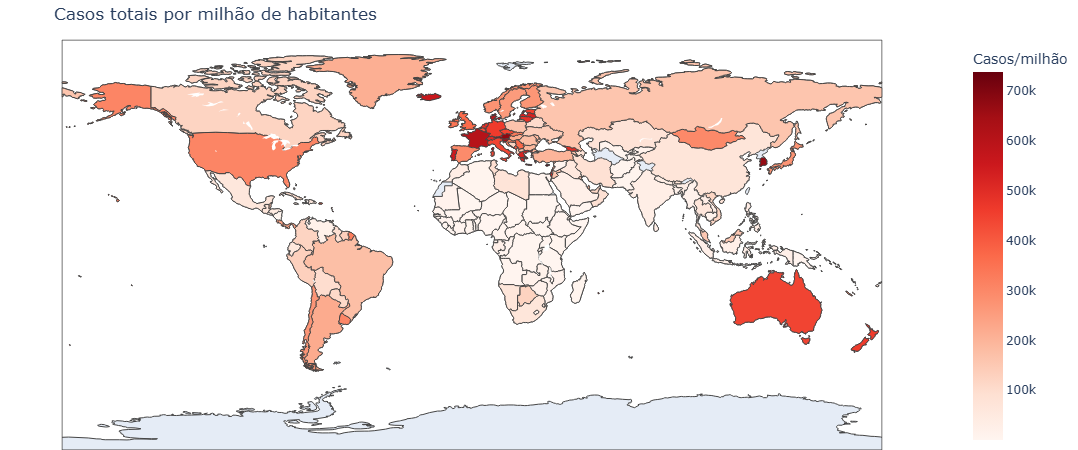

In [13]:
fig_mapa = px.choropleth(
    df_latest,
    locations='iso_code',
    color='total_cases_per_million',
    hover_name='location',
    hover_data={'total_cases': ':,.0f', 'total_deaths': ':,.0f', 'mortality_rate': ':.2f'},
    color_continuous_scale='Reds',
    title='Casos totais por milhão de habitantes',
    labels={'total_cases_per_million': 'Casos/milhão'}
)
fig_mapa.update_layout(height=450, margin=dict(l=0, r=0, t=40, b=0))
fig_mapa.show()

## 4. Gráfico 2 — Top 15 países em casos e mortes

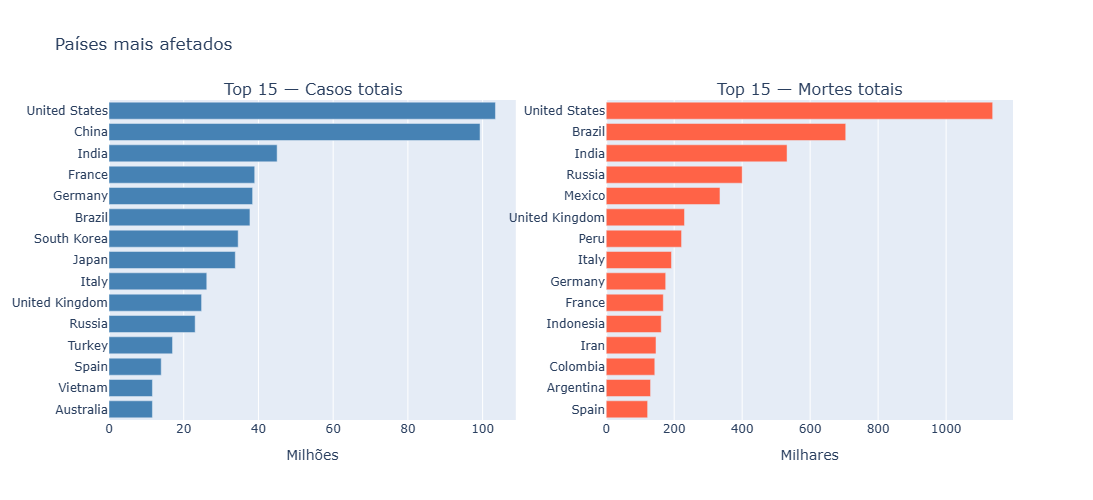

In [14]:
top15_casos = df_latest.nlargest(15, 'total_cases')
top15_mortes = df_latest.nlargest(15, 'total_deaths')

fig_top = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Top 15 — Casos totais', 'Top 15 — Mortes totais')
)

fig_top.add_trace(
    go.Bar(
        x=top15_casos['total_cases'] / 1e6,
        y=top15_casos['location'],
        orientation='h',
        marker_color='steelblue',
        name='Casos (mi)',
        hovertemplate='%{y}: %{x:.1f}M casos<extra></extra>'
    ),
    row=1, col=1
)

fig_top.add_trace(
    go.Bar(
        x=top15_mortes['total_deaths'] / 1e3,
        y=top15_mortes['location'],
        orientation='h',
        marker_color='tomato',
        name='Mortes (mil)',
        hovertemplate='%{y}: %{x:.0f}K mortes<extra></extra>'
    ),
    row=1, col=2
)

fig_top.update_yaxes(autorange='reversed')
fig_top.update_xaxes(title_text='Milhões', row=1, col=1)
fig_top.update_xaxes(title_text='Milhares', row=1, col=2)
fig_top.update_layout(height=500, showlegend=False, title_text='Países mais afetados')
fig_top.show()

## 5. Gráfico 3 — Evolução temporal de casos novos
> Selecione países para comparar

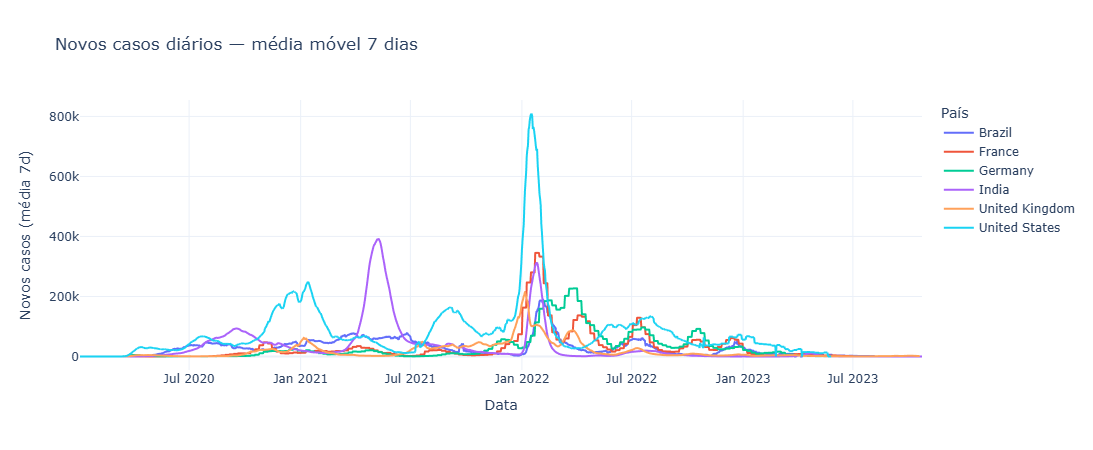

In [15]:
PAISES = ['Brazil', 'United States', 'India', 'Germany', 'France', 'United Kingdom']

df_evolucao = df[df['location'].isin(PAISES)].copy()

# Média móvel de 7 dias para suavizar
df_evolucao = df_evolucao.sort_values(['location', 'date'])
df_evolucao['new_cases_7d'] = (
    df_evolucao.groupby('location')['new_cases']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

fig_evolucao = px.line(
    df_evolucao,
    x='date',
    y='new_cases_7d',
    color='location',
    title='Novos casos diários — média móvel 7 dias',
    labels={'new_cases_7d': 'Novos casos (média 7d)', 'date': 'Data', 'location': 'País'},
    template='plotly_white'
)
fig_evolucao.update_layout(height=450, hovermode='x unified')
fig_evolucao.show()

## 6. Gráfico 4 — Taxa de mortalidade por continente

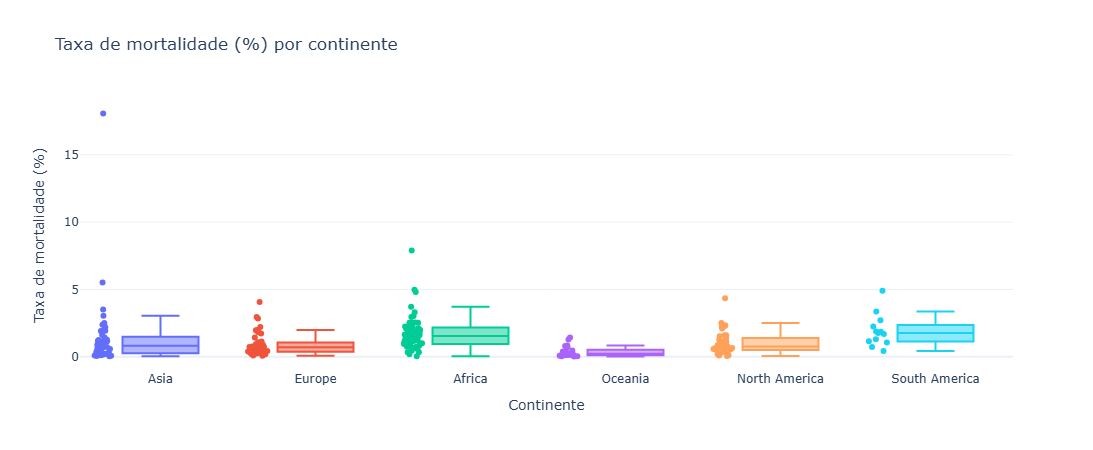

In [16]:
fig_box = px.box(
    df_latest.dropna(subset=['mortality_rate', 'continent']),
    x='continent',
    y='mortality_rate',
    color='continent',
    points='all',
    hover_name='location',
    title='Taxa de mortalidade (%) por continente',
    labels={'mortality_rate': 'Taxa de mortalidade (%)', 'continent': 'Continente'},
    template='plotly_white'
)
fig_box.update_layout(height=450, showlegend=False)
fig_box.show()

## 7. Gráfico 5 — Casos vs. Mortes (scatter por continente)

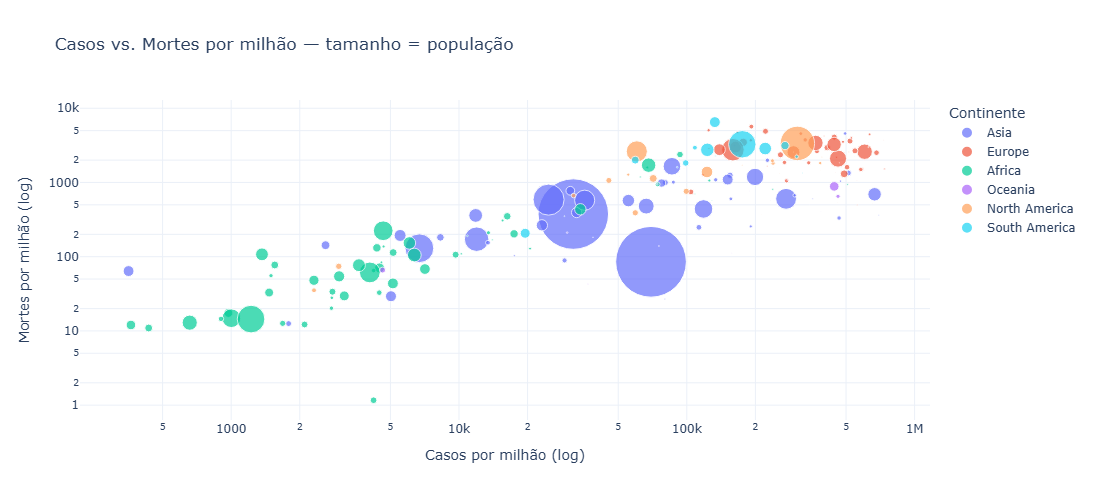

In [17]:
fig_scatter = px.scatter(
    df_latest.dropna(subset=['total_cases_per_million', 'total_deaths_per_million']),
    x='total_cases_per_million',
    y='total_deaths_per_million',
    color='continent',
    size='population',
    hover_name='location',
    size_max=50,
    log_x=True,
    log_y=True,
    title='Casos vs. Mortes por milhão — tamanho = população',
    labels={
        'total_cases_per_million': 'Casos por milhão (log)',
        'total_deaths_per_million': 'Mortes por milhão (log)',
        'continent': 'Continente'
    },
    template='plotly_white'
)
fig_scatter.update_layout(height=500)
fig_scatter.show()

## 8. Exportar dashboard HTML completo

In [18]:
# Combina todos os gráficos num HTML único para compartilhar
from plotly.io import to_html

graficos = [
    ('Mapa Mundial', fig_mapa),
    ('Top 15 Países', fig_top),
    ('Evolução Temporal', fig_evolucao),
    ('Mortalidade por Continente', fig_box),
    ('Casos vs. Mortes', fig_scatter),
]

html_parts = ["""
<!DOCTYPE html>
<html lang='pt-BR'>
<head>
  <meta charset='UTF-8'>
  <title>Dashboard COVID-19</title>
  <style>
    body { font-family: -apple-system, sans-serif; max-width: 1200px; margin: 0 auto; padding: 20px; background: #f9f9f9; }
    h1 { font-size: 26px; color: #1a1a1a; border-bottom: 2px solid #e74c3c; padding-bottom: 10px; }
    h2 { font-size: 16px; color: #555; margin: 30px 0 10px; }
    .chart { background: white; border-radius: 8px; padding: 16px; margin-bottom: 24px; box-shadow: 0 1px 4px rgba(0,0,0,.08); }
    .footer { text-align: center; font-size: 12px; color: #aaa; margin-top: 40px; }
  </style>
</head>
<body>
<h1>Dashboard COVID-19 — Análise Global</h1>
<p style='color:#888;font-size:13px'>Fonte: Our World in Data · Dados acumulados</p>
"""
]

for titulo, fig in graficos:
    html_parts.append(f"<div class='chart'><h2>{titulo}</h2>")
    html_parts.append(to_html(fig, full_html=False, include_plotlyjs='cdn'))
    html_parts.append("</div>")

html_parts.append("<div class='footer'>Projeto de portfólio · Python + Plotly</div></body></html>")

with open('dashboard_covid19.html', 'w', encoding='utf-8') as f:
    f.write(''.join(html_parts))

print('✓ Dashboard exportado: dashboard_covid19.html')
print('  Abra o arquivo no navegador para ver o resultado!')

✓ Dashboard exportado: dashboard_covid19.html
  Abra o arquivo no navegador para ver o resultado!


## 9. Resumo dos insights

In [19]:
print('=' * 55)
print('RESUMO — Dashboard COVID-19')
print('=' * 55)
print(f"Países analisados:   {df_latest['location'].nunique()}")
print(f"Total de casos:      {df_latest['total_cases'].sum():,.0f}")
print(f"Total de mortes:     {df_latest['total_deaths'].sum():,.0f}")
print(f"Taxa mortalidade:    {(df_latest['total_deaths'].sum() / df_latest['total_cases'].sum() * 100):.2f}%")
top_casos = df_latest.nlargest(3, 'total_cases')['location'].tolist()
print(f"Top 3 em casos:      {', '.join(top_casos)}")
top_mortes = df_latest.nlargest(3, 'total_deaths')['location'].tolist()
print(f"Top 3 em mortes:     {', '.join(top_mortes)}")
print('=' * 55)

RESUMO — Dashboard COVID-19
Países analisados:   225
Total de casos:      771,127,728
Total de mortes:     6,968,928
Taxa mortalidade:    0.90%
Top 3 em casos:      United States, China, India
Top 3 em mortes:     United States, Brazil, India
